In [16]:
import numpy as np

# Ask user for file name
filename = input("Enter the file name: ")

# Load the data
data = np.loadtxt(filename)

# Split into x and y arrays
x = data[:,0]
y = data[:,1]

# Print statistics for x
print("Array x:")
print("min =", x.min())
print("max =", x.max())
print("mean =", x.mean())

# Print statistics for y
print("\nArray y:")
print("min =", y.min())
print("max =", y.max())
print("mean =", y.mean())

# Median of y
y_med = np.median(y)

# Compute new array
y2 = (y - y_med)**2

# Print result
print("Array y2:")
print(y2)

Enter the file name:  madeupdata


Array x:
min = 0.05947967
max = 0.87558703
mean = 0.48906671700000004

Array y:
min = 0.05211708
max = 0.86418117
mean = 0.43361472800000006
Array y2:
[1.13322891e-01 1.57050000e-01 1.02873237e-02 1.74511101e-04
 1.66440622e-03 5.74941343e-02 2.26033148e-01 1.28833850e-01
 1.74511101e-04 2.73135270e-03]


In [5]:
import numpy
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print(np.concatenate((a,b))) #6x1 matrix, one dimension, vector
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])
print(np.concatenate((a, b))) #4x2, 2D
print()
print(np.concatenate((a, b), axis=0)) #axis 0 was default, vertical
print()
print(np.concatenate((a, b), axis=1)) #axis 1 is horizontal

[1 2 3 4 5 6]
[[1 2]
 [3 4]
 [5 6]
 [7 8]]

[[1 2]
 [3 4]
 [5 6]
 [7 8]]

[[1 2 5 6]
 [3 4 7 8]]


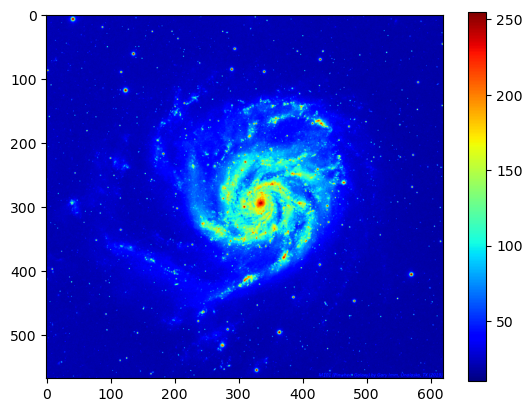

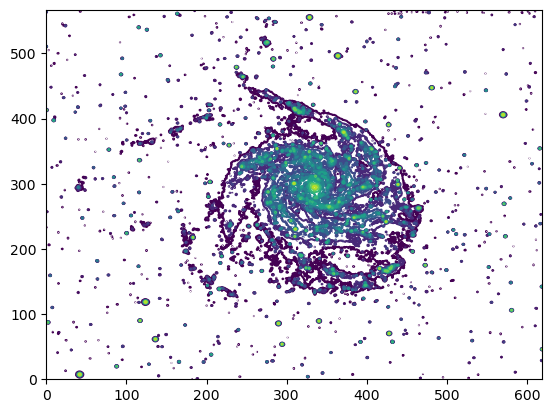

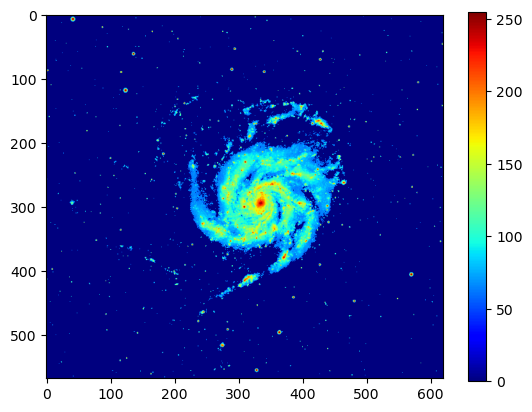

In [14]:
import imageio.v2 as imageio
import numpy as np
import matplotlib.pyplot as plt

data = imageio.imread("m101BW.jpg")

plt.imshow(data, cmap="jet")
plt.colorbar()
plt.show()

levels = np.linspace(np.max(data)*0.2, np.max(data), 10)
plt.contour(data, levels=levels)
plt.show()

threshold = np.percentile(data, 90)
filtered = np.where(data >= threshold, data, 0)

plt.imshow(filtered, cmap="jet")
plt.colorbar()
plt.show()

Max: 0.0606
Min: 0.00482
Sum: 0.89154
Mean: 0.0222885
Std: 0.012699434544498428


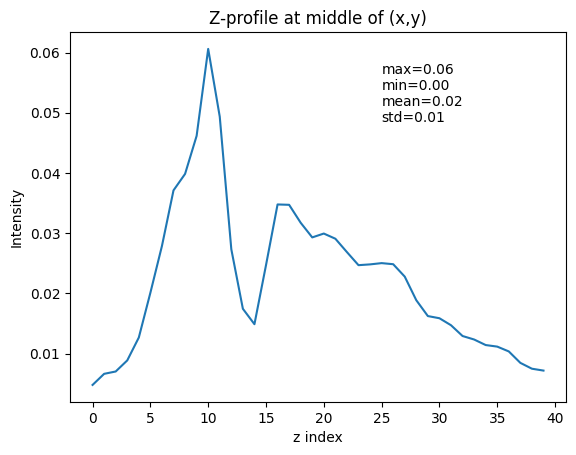

In [10]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("ngc6946")

cube = data.reshape(40, 50, 70)

y_mid = 25
x_mid = 35

z_profile = cube[:, y_mid, x_mid]

z_max = np.max(z_profile)
z_min = np.min(z_profile)
z_sum = np.sum(z_profile)
z_mean = np.mean(z_profile)
z_std = np.std(z_profile)

print("Max:", z_max)
print("Min:", z_min)
print("Sum:", z_sum)
print("Mean:", z_mean)
print("Std:", z_std)

plt.plot(z_profile)
plt.xlabel("z index")
plt.ylabel("Intensity")
plt.title("Z-profile at middle of (x,y)")

text = f"max={z_max:.2f}\nmin={z_min:.2f}\nmean={z_mean:.2f}\nstd={z_std:.2f}"
plt.text(25, z_max*0.8, text)

plt.show()

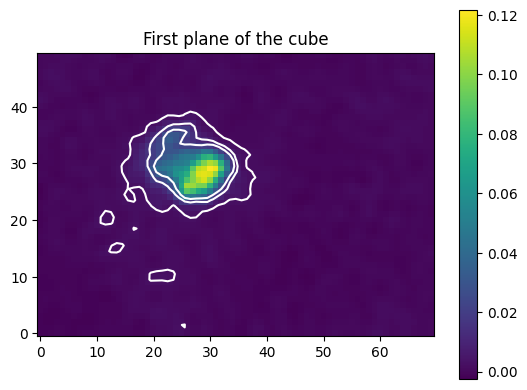

In [7]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("ngc6946")

cube = data.reshape(40, 50, 70)

plane = cube[0, :, :]

plt.imshow(plane, origin="lower")
plt.colorbar()

mean = np.mean(plane)
std = np.std(plane)

levels = [mean, mean + std, mean + 2*std]

plt.contour(plane, levels=levels, colors="white", origin="lower")

plt.title("First plane of the cube")

plt.show()

In [8]:
from scipy.constants import c 
class Galaxy:
    """Class rshift of galaxies"""
    
    caH_0 = 3968.5  # Calcium line
    c = c            # make c a class 
    def __init__(self, name, calciumHline=caH_0):
        self.name = name
        self.caH = calciumHline
    
    def redshift(self):
        # z = Δλ / λ_rest
        z = (self.caH - self.caH_0) / self.caH_0
        return z
    
    def velocity(self):
        # v = c * z
        v = self.c * self.redshift()  # speed in m/s
        return v
gal = Galaxy("NGC1832", 3994.7)

print(f"Galaxy: {gal.name}")
print(f"Redshift: {gal.redshift():.6f}")
print(f"Velocity: {gal.velocity():.2f} m/s")

Galaxy: NGC1832
Redshift: 0.006602
Velocity: 1979227.01 m/s


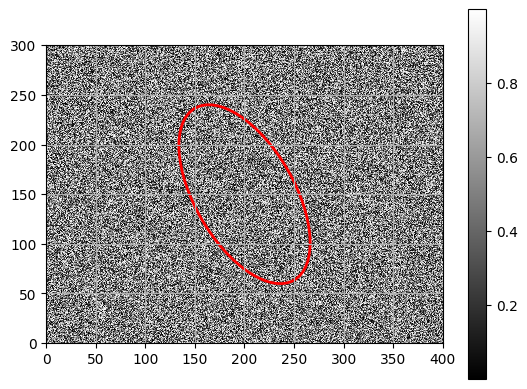

In [15]:
import numpy as np
from matplotlib.pyplot import figure, show, imshow
from matplotlib.patches import Ellipse

Nx = 400
Ny = 300
data = np.random.random((Ny, Nx))

fig = figure()
ax = fig.add_subplot(1, 1, 1)

# Plot the 2D image
im = ax.imshow(data, interpolation='none', origin='lower', cmap='gray')
fig.colorbar(im)

# Ellipse parameters
xcenter = Nx / 2
ycenter = Ny / 2
semi_major = 100
semi_minor = 50
position_angle = 30.0  # degrees

# Add ellipse
ellipse = Ellipse((xcenter, ycenter),
    width=2*semi_minor,
    height=2*semi_major,
    angle=position_angle,
    fill=False,
    color='red',
    linewidth=2
)
ax.add_patch(ellipse)

ax.set_xlim(0, Nx)
ax.set_ylim(0, Ny)
ax.grid(True)

show()